<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/002_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning para identificar clientes com maior risco de cancelamento

**Área:** Machine Learning  
**Nível:** 🟢 Fundamental  
**Tipo de problema:** Classificação binária

### Pergunta de estudo

> Até que ponto modelos supervisionados conseguem identificar clientes propensos a churn e como a escolha do limiar de decisão afeta o equilíbrio entre precisão e recall?

O estudo utiliza o **Iranian Churn Dataset**, disponibilizado pelo UCI Machine Learning Repository.  
O objetivo não é apenas obter uma boa acurácia, mas observar métricas adequadas para uma classe de negócio potencialmente minoritária.

### Modelos

1. Regressão Logística — baseline;
2. Random Forest — modelo não linear;
3. Random Forest com limiar ajustado na validação.

### Métricas

- Accuracy;
- Precision;
- Recall;
- F1-score;
- ROC-AUC;
- Average Precision (área sob a curva Precision-Recall).

> O conjunto de teste é mantido isolado até a avaliação final.


## 1. Configuração do ambiente

O pacote `ucimlrepo` permite carregar o dataset diretamente da UCI.  
As sementes aleatórias são fixadas para aumentar a reprodutibilidade.


In [1]:
# Instala a biblioteca usada para acessar datasets do UCI Machine Learning Repository.
!pip -q install ucimlrepo


In [2]:
# Importações gerais.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)


## 2. Carregamento do dataset

O dataset reúne informações agregadas de clientes de uma operadora de telecomunicações.  
A variável-alvo `Churn` indica se o cliente deixou ou não a empresa.


In [3]:
# Carrega o Iranian Churn Dataset (UCI id=563).
dataset = fetch_ucirepo(id=563)

X = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

# Converte a variável-alvo para uma Series numérica.
y = y_raw.squeeze().astype(int)

print(f"Amostras: {len(X):,}")
print(f"Atributos: {X.shape[1]}")
display(X.head())


Amostras: 3,150
Atributos: 13


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805


In [4]:
# Verifica tipos, valores ausentes e distribuição da variável-alvo.
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "unique": X.nunique(),
})
display(summary)

class_distribution = (
    y.value_counts()
     .sort_index()
     .rename(index={0: "Não churn", 1: "Churn"})
     .to_frame("Quantidade")
)
class_distribution["Percentual"] = (
    class_distribution["Quantidade"] / len(y) * 100
).round(2)

display(class_distribution)


,dtype,missing,unique
Call Failure,int64,0,37
Complains,int64,0,2
Subscription Length,int64,0,45
Charge Amount,int64,0,11
Seconds of Use,int64,0,1756
Frequency of use,int64,0,242
Frequency of SMS,int64,0,405
Distinct Called Numbers,int64,0,92
Age Group,int64,0,5
Tariff Plan,int64,0,2


,Quantidade,Percentual
Churn,,
Não churn,2655,84.29
Churn,495,15.71


## 3. Análise exploratória

Como os atributos são numéricos, é possível inspecionar estatísticas descritivas e correlações lineares com o churn.

Correlação não implica causalidade, mas pode ajudar a identificar variáveis associadas ao comportamento de cancelamento.


In [5]:
# Estatísticas descritivas.
display(X.describe().T)


,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


,Correlação com churn
Complains,0.532053
Status,0.498976
Frequency of use,-0.303337
Seconds of Use,-0.298935
Customer Value,-0.289144
Distinct Called Numbers,-0.278867
Frequency of SMS,-0.220754
Charge Amount,-0.202305
Tariff Plan,-0.105853
Subscription Length,-0.032588


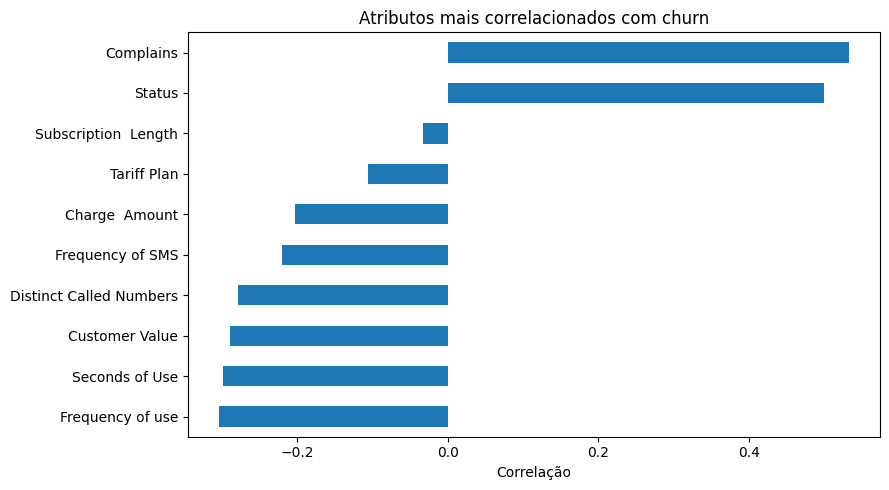

In [6]:
# Correlação absoluta dos atributos com a variável-alvo.
eda_df = X.copy()
eda_df["Churn"] = y.values

correlations = (
    eda_df.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values(key=np.abs, ascending=False)
)

display(correlations.to_frame("Correlação com churn"))

plt.figure(figsize=(9, 5))
correlations.head(10).sort_values().plot(kind="barh")
plt.title("Atributos mais correlacionados com churn")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


## 4. Separação entre treino, validação e teste

A divisão será estratificada para preservar aproximadamente a proporção de churn em cada subconjunto.

- 70% treino;
- 15% validação;
- 15% teste.

A validação será usada para selecionar o limiar de decisão.  
O teste será usado apenas no final.


In [7]:
# Primeira divisão: 70% treino e 30% validação + teste.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

# Segunda divisão: metade do conjunto temporário para validação e metade para teste.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

split_summary = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Amostras": [len(X_train), len(X_val), len(X_test)],
    "Taxa de churn": [y_train.mean(), y_val.mean(), y_test.mean()],
})
split_summary["Taxa de churn"] = (split_summary["Taxa de churn"] * 100).round(2)

display(split_summary)


,Conjunto,Amostras,Taxa de churn
0,Treino,2205,15.74
1,Validação,472,15.68
2,Teste,473,15.64


## 5. Baseline — Regressão Logística

A Regressão Logística fornece um baseline simples, rápido e interpretável.

A padronização é ajustada **somente no conjunto de treino**, evitando vazamento de informação.


In [8]:
# Ajusta o scaler apenas com dados de treino.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Class weight ajuda o modelo a considerar a classe minoritária.
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
)

baseline_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

## 6. Random Forest

Random Forest combina múltiplas árvores de decisão e consegue representar relações não lineares e interações entre atributos.

`class_weight="balanced"` ajusta automaticamente o peso das classes de acordo com sua frequência.


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=400, n_jobs=-1, random_state=42)

## 7. Ajuste do limiar de decisão

Classificadores binários normalmente usam `0.5` como limiar padrão.  
Entretanto, em churn, perder um cliente de risco pode ser mais custoso do que abordar um cliente que acabaria permanecendo.

Aqui o limiar é escolhido **somente na validação**, buscando maximizar o F1-score da classe churn.


Melhor limiar na validação: 0.44


,Resultado
threshold,0.440000
precision,0.886076
recall,0.945946
f1,0.915033


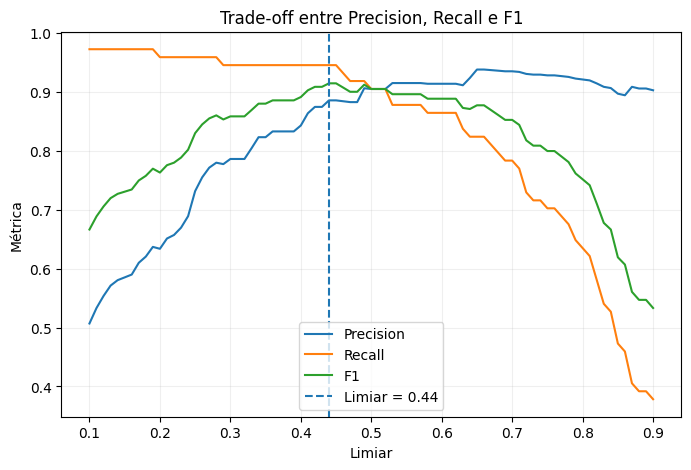

In [10]:
# Probabilidades de churn na validação.
val_probabilities = rf_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    predictions = (val_probabilities >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, predictions, zero_division=0),
        "recall": recall_score(y_val, predictions, zero_division=0),
        "f1": f1_score(y_val, predictions, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = float(best_row["threshold"])

print(f"Melhor limiar na validação: {best_threshold:.2f}")
display(best_row.to_frame("Resultado"))

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Limiar = {best_threshold:.2f}")
plt.xlabel("Limiar")
plt.ylabel("Métrica")
plt.title("Trade-off entre Precision, Recall e F1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 8. Avaliação final

O conjunto de teste é utilizado somente agora.

Serão comparados:

- Regressão Logística com limiar 0.5;
- Random Forest com limiar 0.5;
- Random Forest com limiar ajustado na validação.


In [11]:
def classification_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Average Precision": average_precision_score(y_true, probabilities),
    }, predictions

baseline_probabilities = baseline_model.predict_proba(X_test_scaled)[:, 1]
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

baseline_metrics, baseline_predictions = classification_metrics(
    y_test, baseline_probabilities, threshold=0.5
)
rf_default_metrics, rf_default_predictions = classification_metrics(
    y_test, rf_probabilities, threshold=0.5
)
rf_tuned_metrics, rf_tuned_predictions = classification_metrics(
    y_test, rf_probabilities, threshold=best_threshold
)

results = pd.DataFrame([
    {"Modelo": "Regressão Logística", **baseline_metrics},
    {"Modelo": "Random Forest (0.50)", **rf_default_metrics},
    {"Modelo": f"Random Forest ({best_threshold:.2f})", **rf_tuned_metrics},
]).set_index("Modelo")

display(results.round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Modelo,,,,,,
Regressão Logística,0.8309,0.4779,0.8784,0.6190,0.9214,0.709
Random Forest (0.50),0.9577,0.8553,0.8784,0.8667,0.9847,0.912
Random Forest (0.44),0.9429,0.7831,0.8784,0.8280,0.9847,0.912


In [12]:
# Relatórios de classificação.
print("REGRESSÃO LOGÍSTICA")
print(classification_report(y_test, baseline_predictions, target_names=["Não churn", "Churn"]))

print("\nRANDOM FOREST — LIMIAR AJUSTADO")
print(classification_report(y_test, rf_tuned_predictions, target_names=["Não churn", "Churn"]))


REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

   Não churn       0.97      0.82      0.89       399
       Churn       0.48      0.88      0.62        74

    accuracy                           0.83       473
   macro avg       0.73      0.85      0.76       473
weighted avg       0.90      0.83      0.85       473


RANDOM FOREST — LIMIAR AJUSTADO
              precision    recall  f1-score   support

   Não churn       0.98      0.95      0.97       399
       Churn       0.78      0.88      0.83        74

    accuracy                           0.94       473
   macro avg       0.88      0.92      0.90       473
weighted avg       0.95      0.94      0.94       473



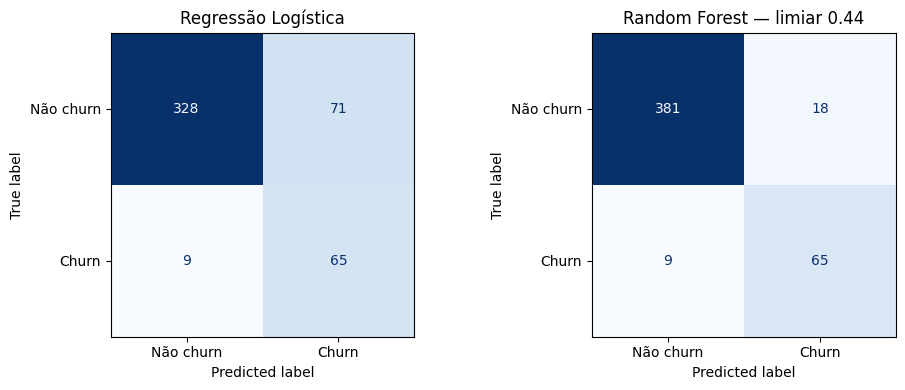

In [13]:
# Matrizes de confusão.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=["Não churn", "Churn"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Regressão Logística")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_tuned_predictions,
    display_labels=["Não churn", "Churn"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Random Forest — limiar {best_threshold:.2f}")

plt.tight_layout()
plt.show()


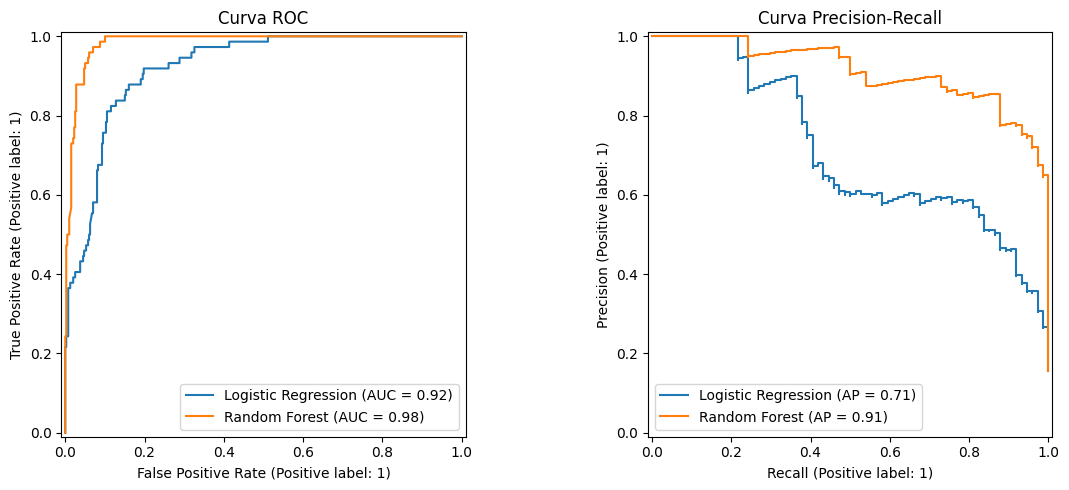

In [14]:
# Curvas ROC e Precision-Recall.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, baseline_probabilities, name="Logistic Regression", ax=axes[0]
)
RocCurveDisplay.from_predictions(
    y_test, rf_probabilities, name="Random Forest", ax=axes[0]
)
axes[0].set_title("Curva ROC")

PrecisionRecallDisplay.from_predictions(
    y_test, baseline_probabilities, name="Logistic Regression", ax=axes[1]
)
PrecisionRecallDisplay.from_predictions(
    y_test, rf_probabilities, name="Random Forest", ax=axes[1]
)
axes[1].set_title("Curva Precision-Recall")

plt.tight_layout()
plt.show()


## 9. Importância dos atributos

A importância calculada pela Random Forest não representa causalidade.  
Ela indica apenas quanto cada atributo contribuiu para as divisões realizadas pelas árvores do modelo.


,Importância
Status,0.168829
Seconds of Use,0.136747
Frequency of use,0.127330
Complains,0.126440
Customer Value,0.099957
Subscription Length,0.087141
Distinct Called Numbers,0.074405
Frequency of SMS,0.066847
Call Failure,0.041738
Age,0.025225


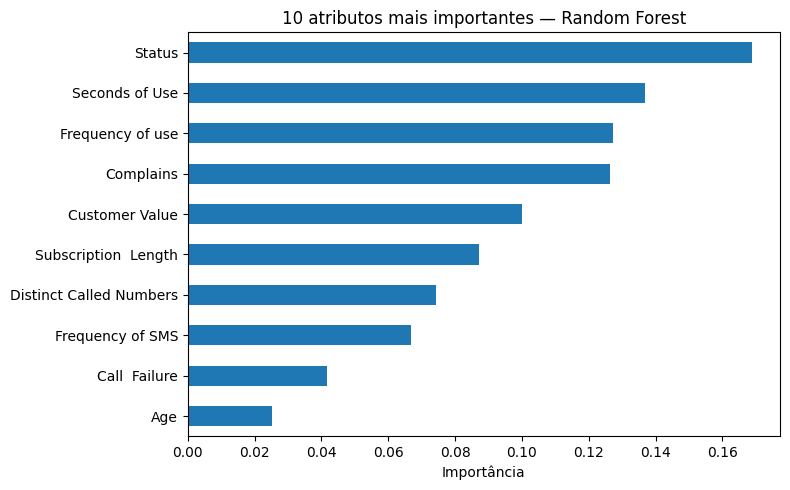

In [15]:
feature_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
)

display(feature_importance.to_frame("Importância"))

plt.figure(figsize=(8, 5))
feature_importance.sort_values().plot(kind="barh")
plt.title("10 atributos mais importantes — Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()


## 10. Conclusão

A célula abaixo produz uma síntese baseada nos resultados efetivamente obtidos na execução atual.


In [16]:
from IPython.display import Markdown, display

best_model_name = results["F1"].idxmax()
best_f1 = results.loc[best_model_name, "F1"]
best_recall = results.loc[best_model_name, "Recall"]
best_auc = results.loc[best_model_name, "ROC-AUC"]

conclusion = f'''
### Síntese dos resultados

O melhor resultado de **F1 para churn** foi obtido por **{best_model_name}**, com:

- **F1:** {best_f1:.3f}
- **Recall:** {best_recall:.3f}
- **ROC-AUC:** {best_auc:.3f}

O experimento mostra que avaliar churn apenas por acurácia pode esconder erros relevantes na classe de interesse.
O ajuste de limiar permite alterar explicitamente o equilíbrio entre **Precision** e **Recall**, sem retreinar o modelo.

### Limitações

- O dataset representa uma única empresa e contexto;
- as variáveis são agregadas e não capturam toda a dinâmica temporal do cliente;
- não foi atribuído um custo financeiro diferente para falsos positivos e falsos negativos;
- importância de atributos não deve ser interpretada como relação causal.

### Próximos experimentos

1. testar Gradient Boosting/XGBoost;
2. usar validação cruzada;
3. calibrar probabilidades;
4. otimizar o limiar com uma função de custo de negócio;
5. avaliar explicabilidade com SHAP.
'''

display(Markdown(conclusion))



### Síntese dos resultados

O melhor resultado de **F1 para churn** foi obtido por **Random Forest (0.50)**, com:

- **F1:** 0.867
- **Recall:** 0.878
- **ROC-AUC:** 0.985

O experimento mostra que avaliar churn apenas por acurácia pode esconder erros relevantes na classe de interesse. 
O ajuste de limiar permite alterar explicitamente o equilíbrio entre **Precision** e **Recall**, sem retreinar o modelo.

### Limitações

- O dataset representa uma única empresa e contexto;
- as variáveis são agregadas e não capturam toda a dinâmica temporal do cliente;
- não foi atribuído um custo financeiro diferente para falsos positivos e falsos negativos;
- importância de atributos não deve ser interpretada como relação causal.

### Próximos experimentos

1. testar Gradient Boosting/XGBoost;
2. usar validação cruzada;
3. calibrar probabilidades;
4. otimizar o limiar com uma função de custo de negócio;
5. avaliar explicabilidade com SHAP.


## Referência do dataset

Iranian Churn Dataset — UCI Machine Learning Repository  
DOI: `10.24432/C5JW3Z`
